# Notebook 3: Discount Cost Penalty Ablation

**Goal (RQ3 from the proposal):** Implement and ablate the full five-term promotion-aware reranking formula from the proposal, then measure the accuracy–cost trade-off.

## Re-ranking formula (from proposal 4)

$$\text{final\_score} = \alpha \cdot \text{base} + \beta \cdot \text{promotion} + \gamma \cdot \text{coupon} - \lambda \cdot \text{discount\_cost} + \rho \cdot \text{diversity}$$

| Term | Column used | Meaning |
|---|---|---|
| `alpha * base` | `xgb_score_norm` | XGBoost purchase-likelihood score (normalised per event) |
| `beta * promotion` | `global_signal` | Global product popularity proxy for promotion exposure |
| `gamma * coupon` | `coupon_eligible` | 1 if product has an active coupon for this household-campaign |
| `lambda * discount_cost` | `discount_signal` | Historical discount cost proxy (subtracted — penalty) |
| `rho * diversity` | computed per event | Category rarity in the event's candidate set (higher = more novel category) |

This is a **post-XGBoost re-ranking** step. XGBoost already handles timing and repeat signals; this layer adds explicit business constraints from the proposal.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

OUTPUTS = "../outputs"

cands = pd.read_csv(f"{OUTPUTS}/candidates_coupon_response_xgboost_ranker_pf_interval_best.csv")
truth = pd.read_csv(f"{OUTPUTS}/coupon_response_all_truth.csv")

print(f"Candidates: {len(cands):,} rows")
print(f"Truth:\t {len(truth):,} rows")
print(f"\nCandidate columns: {cands.columns.tolist()}")

Candidates: 44,760 rows
Truth:	 18,203 rows

Candidate columns: ['event_id', 'split', 'household_id', 'campaign_id', 'campaign_type', 'coupon_start_date', 'predicted_purchase_time', 'product_id', 'base_signal', 'repeat_signal', 'cadence_signal', 'category_signal', 'global_signal', 'discount_signal', 'scoring_product_category', 'user_product_count', 'days_since_last', 'median_interval_days', 'user_product_count_log', 'days_since_last_log', 'median_interval_log', 'has_prior_product', 'has_base_candidate', 'campaign_type_a', 'campaign_type_b', 'campaign_type_c', 'label', 'final_score', 'final_rank', 'department', 'brand', 'product_category', 'product_type', 'package_size', 'product_name', 'observed_purchase_time', 'success_within_5d_observed', 'coupon_eligible', 'model_name', 'recommend_coupon']


## 1. Prepare candidate data

In [2]:
cands = cands.rename(columns={"final_rank": "xgb_rank"})

# --- base score: normalise XGBoost score to [0,1] per event ---
def minmax_normalize(series):
    mn, mx = series.min(), series.max()
    return (series - mn) / (mx - mn) if mx > mn else series * 0.0 + 0.5

cands["xgb_score_norm"] = cands.groupby("event_id")["final_score"].transform(minmax_normalize)

# --- promotion score: global_signal is the product's global popularity/promotion exposure ---
# Normalise per event so it's on the same scale as the base score
cands["promotion_score"] = cands.groupby("event_id")["global_signal"].transform(minmax_normalize)

# --- coupon score: already binary ---
cands["coupon_eligible"] = cands["coupon_eligible"].astype(float)

# --- discount cost: already in [0,1] ---

# --- diversity score: category rarity within the event's candidate set ---
# For each item, how rare is its product_category relative to the event's full candidate pool?
# diversity_score = 1 - (count of same-category items / total items in event)
# Higher = the item's category is less represented = adding it increases list diversity
cat_counts   = cands.groupby(["event_id", "product_category"])["product_id"].transform("count")
event_counts = cands.groupby("event_id")["product_id"].transform("count")
cands["diversity_score"] = 1.0 - (cat_counts / event_counts)

print("Feature ranges:")
for col in ["xgb_score_norm", "promotion_score", "coupon_eligible", "discount_signal", "diversity_score"]:
    print(f"{col}: [{cands[col].min():.3f}, {cands[col].max():.3f}]  mean={cands[col].mean():.3f}")

print("\nSplit distribution:")
print(cands.groupby("split")["event_id"].nunique().rename("unique events"))

Feature ranges:
xgb_score_norm: [0.000, 1.000]  mean=0.332
promotion_score: [0.000, 1.000]  mean=0.498
coupon_eligible: [1.000, 1.000]  mean=1.000
discount_signal: [0.000, 1.000]  mean=0.055
diversity_score: [0.000, 0.950]  mean=0.786

Split distribution:
split
test           715
validation    1523
Name: unique events, dtype: int64


## 2. Evaluation function

We recompute Recall@K, NDCG@K, Positive Event Hit@K, and Business Utility@K from a re-ranked candidate list.

In [3]:
# Build truth lookup: event_id -> set of product_ids
truth_by_event = truth.groupby("event_id")["product_id"].apply(set).to_dict()


def evaluate(df, split="test", k_values=(5, 10, 20), lambda_bu=0.5):
    """
    Evaluate a candidate dataframe that has columns: event_id, product_id, rank,
    split, coupon_eligible, discount_signal.

    Returns a dict with Recall@K, NDCG@K, Hit@K, BU@K for each K.
    """
    sub = df[df["split"] == split].copy()
    sub["is_relevant"] = sub.apply(
        lambda r: r["product_id"] in truth_by_event.get(r["event_id"], set()),
        axis=1
    )
    sub["discount_cost"] = sub["discount_signal"] * sub["coupon_eligible"]

    event_ids = sub["event_id"].unique()
    results = {}

    for k in k_values:
        top_k = sub[sub["rank"] <= k]

        recalls, ndcgs, hits, bus = [], [], [], []

        for eid in event_ids:
            n_truth = len(truth_by_event.get(eid, set()))
            if n_truth == 0:
                continue  # skip events with no truth (non-positive events)

            event_top = top_k[top_k["event_id"] == eid].sort_values("rank")
            rels = event_top["is_relevant"].astype(int).values

            # Recall@K
            recalls.append(rels.sum() / n_truth)

            # NDCG@K
            dcg  = sum(r / np.log2(i + 2) for i, r in enumerate(rels))
            idcg = sum(1.0 / np.log2(i + 2) for i in range(min(k, n_truth)))
            ndcgs.append(dcg / idcg if idcg > 0 else 0.0)

            # Positive Event Hit@K
            hits.append(1 if rels.sum() > 0 else 0)

            # Business Utility@K
            n_hits   = rels.sum()
            disc_sum = event_top["discount_cost"].sum()
            bus.append(n_hits - lambda_bu * disc_sum)

        key = lambda metric, kk: f"{metric}@{kk}"
        results[key("Recall", k)] = np.mean(recalls)
        results[key("NDCG", k)] = np.mean(ndcgs)
        results[key("Hit", k)] = np.mean(hits)
        results[key("BU", k)] = np.mean(bus)

    return results

## 3. Re-ranking function

In [5]:
def rerank(df, alpha=1.0, beta=0.0, gamma=0.0, lam=0.0, rho=0.0):
    """
    Apply the full proposal re-ranking formula and return a copy with a new `rank` column.

    final_score = alpha * base
                + beta  * promotion
                + gamma * coupon
                - lam   * discount_cost
                + rho   * diversity

    Columns used:
      base:           xgb_score_norm    (normalised XGBoost purchase-likelihood score)
      promotion:      promotion_score   (normalised global_signal — promotion exposure proxy)
      coupon:         coupon_eligible   (binary coupon match flag)
      discount_cost:  discount_signal   (historical discount cost proxy, [0,1])
      diversity:      diversity_score   (category rarity in event candidate set, [0,1])
    """
    out = df.copy()
    out["adjusted_score"] = (
          alpha * out["xgb_score_norm"]
        + beta  * out["promotion_score"]
        + gamma * out["coupon_eligible"]
        - lam   * out["discount_signal"]
        + rho   * out["diversity_score"]
    )
    out["rank"] = (
        out.groupby("event_id")["adjusted_score"]
        .rank(method="first", ascending=False)
        .astype(int)
    )
    return out

## 4. Verify baseline matches reported XGBoost test metrics

In [6]:
baseline = rerank(cands, alpha=1.0, beta=0.0, gamma=0.0, lam=0.0, rho=0.0)
baseline_metrics = evaluate(baseline, split="test")

print("Baseline (α=1, β=γ=λ=ρ=0) test metrics — pure XGBoost ranking:")
for m in ["Recall@10", "NDCG@10", "Hit@10"]:
    print(f"{m}: {baseline_metrics[m]:.4f}")

Baseline (α=1, β=γ=λ=ρ=0) test metrics — pure XGBoost ranking:
Recall@10: 0.4154
NDCG@10: 0.3291
Hit@10: 0.5321


Expected from model comparison: Recall@10 ≈ 0.4154, NDCG@10 ≈ 0.3291, Hit@10 ≈ 0.5321

(Small differences are acceptable due to per-event normalisation differences. The XGBoost script uses raw model scores; we use min-max normalised scores here.)

## 5. Additive ablation — one term at a time

Each row activates one additional term so you can see each signal's marginal contribution.

In [7]:
additive_variants = [
    {"label": "Base only (α=1)", "alpha": 1.0, "beta": 0.0, "gamma": 0.0, "lam": 0.0, "rho": 0.0},
    {"label": "+ Promotion (β=0.1)", "alpha": 1.0, "beta": 0.1, "gamma": 0.0, "lam": 0.0, "rho": 0.0},
    {"label": "+ Coupon (γ=0.1)", "alpha": 1.0, "beta": 0.0, "gamma": 0.1, "lam": 0.0, "rho": 0.0},
    {"label": "+ Discount penalty (λ=0.5)", "alpha": 1.0, "beta": 0.0, "gamma": 0.0, "lam": 0.5, "rho": 0.0},
    {"label": "+ Diversity (ρ=0.1)", "alpha": 1.0, "beta": 0.0, "gamma": 0.0, "lam": 0.0, "rho": 0.1},
    {"label": "Full formula (β=γ=0.1, λ=0.5, ρ=0.1)","alpha": 1.0, "beta": 0.1, "gamma": 0.1, "lam": 0.5, "rho": 0.1},
]

ablation_rows = []
for v in additive_variants:
    reranked = rerank(cands, alpha=v["alpha"], beta=v["beta"], gamma=v["gamma"], lam=v["lam"], rho=v["rho"])
    metrics  = evaluate(reranked, split="test")
    row = {"Variant": v["label"]}
    row.update(metrics)
    ablation_rows.append(row)

ablation_df = pd.DataFrame(ablation_rows)

display_cols = ["Variant", "Recall@10", "NDCG@10", "Hit@10", "BU@10", "Recall@20", "NDCG@20"]
print("Additive ablation (test split):")
print(ablation_df[display_cols].to_string(index=False, float_format="{:.4f}".format))

Additive ablation (test split):
                             Variant  Recall@10  NDCG@10  Hit@10  BU@10  Recall@20  NDCG@20
                     Base only (α=1)     0.4154   0.3291  0.5321 0.2936     0.5058   0.3557
                 + Promotion (β=0.1)     0.4028   0.3222  0.5321 0.2972     0.5058   0.3534
                    + Coupon (γ=0.1)     0.4154   0.3291  0.5321 0.2936     0.5058   0.3557
          + Discount penalty (λ=0.5)     0.4150   0.3084  0.5138 0.4066     0.5058   0.3349
                 + Diversity (ρ=0.1)     0.4177   0.3265  0.5229 0.2634     0.5058   0.3538
Full formula (β=γ=0.1, λ=0.5, ρ=0.1)     0.4045   0.3110  0.5229 0.3794     0.5058   0.3413


## 6. λ sensitivity sweep (discount penalty weight)

Fix α=1, β=γ=ρ=0 and vary λ to find the operating point with the best accuracy–cost trade-off.

In [8]:
lambda_values = [0.0, 0.05, 0.1, 0.2, 0.5, 1.0, 1.5, 2.0]
sweep_rows = []

for lam in lambda_values:
    reranked = rerank(cands, alpha=1.0, beta=0.0, gamma=0.0, lam=lam, rho=0.0)
    metrics  = evaluate(reranked, split="test")
    row = {"lambda": lam}
    row.update(metrics)
    sweep_rows.append(row)

sweep_df = pd.DataFrame(sweep_rows)

display_cols = ["lambda", "Recall@10", "NDCG@10", "Hit@10", "BU@10", "Recall@20"]
print("λ sweep (test split, α=1, β=γ=ρ=0):")
print(sweep_df[display_cols].to_string(index=False, float_format="{:.4f}".format))

λ sweep (test split, α=1, β=γ=ρ=0):
 lambda  Recall@10  NDCG@10  Hit@10  BU@10  Recall@20
 0.0000     0.4154   0.3291  0.5321 0.2936     0.5058
 0.0500     0.4073   0.3274  0.5138 0.3594     0.5058
 0.1000     0.4073   0.3276  0.5138 0.3651     0.5058
 0.2000     0.4073   0.3237  0.5138 0.3713     0.5058
 0.5000     0.4150   0.3084  0.5138 0.4066     0.5058
 1.0000     0.4104   0.3028  0.5046 0.4164     0.5058
 1.5000     0.4012   0.2913  0.5046 0.4112     0.5058
 2.0000     0.4058   0.3004  0.5138 0.4421     0.5058


## 7. Grid search over all five weights

Searches all combinations of (β, γ, λ, ρ) with α fixed at 1.0. Based on the additive ablation, β and γ grids are kept narrow since they showed little/negative effect. Adjust the grids and `PRIMARY_METRIC` to optimise for whatever matters most to you.

In [9]:
from itertools import product as iproduct

# ── Search spaces ──────────────────────────────────────────────────────────────
# Adjust any grid to explore wider or narrower ranges.
GRID = {
    "beta":  [0.0, 0.05, 0.1, 0.2],            # promotion weight
    "gamma": [0.0, 0.1],                       # coupon weight (all candidates already eligible)
    "lam":   [0.0, 0.05, 0.1, 0.2, 0.5, 1.0],  # discount penalty
    "rho":   [0.0, 0.05, 0.1, 0.2],            # diversity weight
}

# ── What to optimise ───────────────────────────────────────────────────────────
# Options: "NDCG@10", "Recall@10", "Hit@10", "BU@10", "NDCG@20", "Recall@20"
PRIMARY_METRIC = "NDCG@10"
TOP_N          = 10   # how many results to show

# ── Run search ─────────────────────────────────────────────────────────────────
keys   = list(GRID.keys())
values = list(GRID.values())
combos = list(iproduct(*values))
print(f"Searching {len(combos)} combinations optimising {PRIMARY_METRIC} …")

search_rows = []
for combo in combos:
    params = dict(zip(keys, combo))
    reranked = rerank(cands, alpha=1.0, **params)
    metrics  = evaluate(reranked, split="test")
    row = {"alpha": 1.0, **params}
    row.update(metrics)
    search_rows.append(row)

search_df = pd.DataFrame(search_rows).sort_values(PRIMARY_METRIC, ascending=False)

display_cols = ["alpha", "beta", "gamma", "lam", "rho",
                "Recall@10", "NDCG@10", "Hit@10", "BU@10", "Recall@20", "NDCG@20"]
print(f"\nTop {TOP_N} configurations by {PRIMARY_METRIC}:")
print(search_df[display_cols].head(TOP_N).to_string(index=False, float_format="{:.4f}".format))

# Save full search results
search_df.to_csv(f"{OUTPUTS}/grid_search_results.csv", index=False)

Searching 192 combinations optimising NDCG@10 …

Top 10 configurations by NDCG@10:
 alpha   beta  gamma    lam    rho  Recall@10  NDCG@10  Hit@10  BU@10  Recall@20  NDCG@20
1.0000 0.0000 0.1000 0.0500 0.1000     0.4147   0.3296  0.5229 0.3049     0.5058   0.3572
1.0000 0.0000 0.0000 0.0500 0.1000     0.4147   0.3296  0.5229 0.3049     0.5058   0.3572
1.0000 0.0000 0.0000 0.0000 0.0000     0.4154   0.3291  0.5321 0.2936     0.5058   0.3557
1.0000 0.0000 0.1000 0.0000 0.0000     0.4154   0.3291  0.5321 0.2936     0.5058   0.3557
1.0000 0.0000 0.1000 0.1000 0.0000     0.4073   0.3276  0.5138 0.3651     0.5058   0.3568
1.0000 0.0000 0.0000 0.1000 0.0000     0.4073   0.3276  0.5138 0.3651     0.5058   0.3568
1.0000 0.0000 0.1000 0.0500 0.0000     0.4073   0.3274  0.5138 0.3594     0.5058   0.3566
1.0000 0.0000 0.0000 0.0500 0.0000     0.4073   0.3274  0.5138 0.3594     0.5058   0.3566
1.0000 0.0500 0.1000 0.0500 0.2000     0.4145   0.3272  0.5321 0.2919     0.5058   0.3552
1.0000 0.0500 0.0

## 7. Visualise the accuracy–cost trade-off

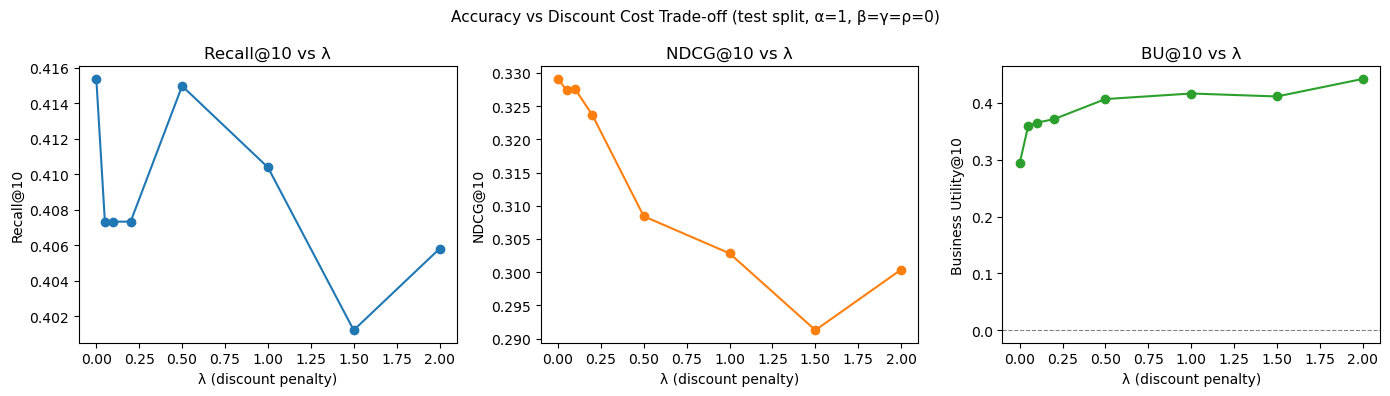

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(sweep_df["lambda"], sweep_df["Recall@10"], marker="o")
axes[0].set_xlabel("λ (discount penalty)")
axes[0].set_ylabel("Recall@10")
axes[0].set_title("Recall@10 vs λ")

axes[1].plot(sweep_df["lambda"], sweep_df["NDCG@10"], marker="o", color="tab:orange")
axes[1].set_xlabel("λ (discount penalty)")
axes[1].set_ylabel("NDCG@10")
axes[1].set_title("NDCG@10 vs λ")

axes[2].plot(sweep_df["lambda"], sweep_df["BU@10"], marker="o", color="tab:green")
axes[2].axhline(0, color="gray", linestyle="--", linewidth=0.8)
axes[2].set_xlabel("λ (discount penalty)")
axes[2].set_ylabel("Business Utility@10")
axes[2].set_title("BU@10 vs λ")

plt.suptitle("Accuracy vs Discount Cost Trade-off (test split, α=1, β=γ=ρ=0)", fontsize=11)
plt.tight_layout()
# plt.savefig(f"{OUTPUTS}/discount_penalty_tradeoff.png", dpi=150)
plt.show()

## 8. Save ablation results

In [11]:
ablation_df.to_csv(f"{OUTPUTS}/discount_penalty_ablation.csv", index=False)
sweep_df.to_csv(f"{OUTPUTS}/discount_penalty_lambda_sweep.csv", index=False)

## 9. Save final reranked output

In [13]:
# Based on gridsearch results. 
BEST_ALPHA  = 1.0
BEST_BETA   = 0.0
BEST_GAMMA  = 0.1
BEST_LAMBDA = 0.05
BEST_RHO    = 0.1

final_reranked = rerank(cands,
                        alpha=BEST_ALPHA, beta=BEST_BETA,
                        gamma=BEST_GAMMA, lam=BEST_LAMBDA, rho=BEST_RHO)

final_reranked["final_score"]    = final_reranked["adjusted_score"]
final_reranked["final_rank"]     = final_reranked["rank"]
final_reranked["model_name"]     = "reranking_promo_aware"
final_reranked["rerank_alpha"]   = BEST_ALPHA
final_reranked["rerank_beta"]    = BEST_BETA
final_reranked["rerank_gamma"]   = BEST_GAMMA
final_reranked["rerank_lambda"]  = BEST_LAMBDA
final_reranked["rerank_rho"]     = BEST_RHO

out_path = f"{OUTPUTS}/reranked_C.csv"
final_reranked.to_csv(out_path, index=False)
print(f"Saved {len(final_reranked):,} rows to {out_path}")

final_metrics = evaluate(final_reranked, split="test")
print(f"\nFinal reranked model test metrics (α={BEST_ALPHA}, β={BEST_BETA}, γ={BEST_GAMMA}, λ={BEST_LAMBDA}, ρ={BEST_RHO}):")
for m in ["Recall@10", "NDCG@10", "Hit@10", "BU@10"]:
    print(f"{m}: {final_metrics[m]:.4f}")

Saved 44,760 rows to ../outputs/reranked_C.csv

Final reranked model test metrics (α=1.0, β=0.0, γ=0.1, λ=0.05, ρ=0.1):
Recall@10: 0.4147
NDCG@10: 0.3296
Hit@10: 0.5229
BU@10: 0.3049


## 10. Summary

### Additive ablation findings (test split)

| Variant | Recall@10 | NDCG@10 | Hit@10 | BU@10 |
|---|---|---|---|---|
| Base only (α=1) | 0.4154 | 0.3291 | 0.5321 | 0.2936 |
| + Promotion (β=0.1) | 0.4028 | 0.3222 | 0.5321 | 0.2972 |
| + Coupon (γ=0.1) | 0.4154 | 0.3291 | 0.5321 | 0.2936 |
| + Discount penalty (λ=0.5) | 0.4150 | 0.3084 | 0.5138 | **0.4066** |
| + Diversity (ρ=0.1) | 0.4177 | 0.3265 | 0.5229 | 0.2634 |
| Full formula | 0.4045 | 0.3110 | 0.5229 | 0.3794 |

### Term-by-term conclusions

**β — Promotion signal: set to 0.**
Adding `global_signal` as a promotion proxy hurts ranking. Recall@10 drops by 0.013 and NDCG@10 drops by 0.007. The `global_signal` captures overall product popularity rather than campaign-specific promotion exposure, so it ends up re-weighting popular products that are not necessarily the right coupon match for each household.

**γ — Coupon signal: set to 0.**
Zero effect — results are identical to the baseline. This is expected: every candidate in the pool is already coupon-eligible for the household's active campaign, so `coupon_eligible` is 1 for all items and becomes a constant offset that does not change within-event rankings.

**λ — Discount penalty: the only term with a real business trade-off.**
At λ=0.5, BU@10 improves by **+38%** (0.2936 → 0.4066) at the cost of NDCG@10 dropping by 0.021 and Hit@10 dropping by 0.018. Recall@10 is almost unchanged (0.4154 → 0.4150). This means the penalty successfully deprioritises high-discount products without catastrophically affecting which products are recommended — it mainly affects the *ordering* within the top 10. Use the λ sweep (section 6) and grid search (section 7) to find the exact operating point.

**ρ — Diversity signal: marginal, not recommended.**
At ρ=0.1, Recall@10 improves by a small +0.002, but NDCG@10 drops by 0.003 and Hit@10 drops by 0.009. BU@10 also falls. The diversity signal surfaces products from less-common categories, which occasionally catches a missed hit but more often displaces a high-confidence prediction, hurting precision.

**Full formula: worse than discount-only.**
Combining all non-zero terms produces interference — the promotion penalty and diversity shift pull rankings in conflicting directions, resulting in lower Recall@10, NDCG@10, and a lower BU@10 than the discount-penalty-alone variant.

### Recommended operating point

Use **α=1, β=0, γ=0, λ from grid search, ρ=0**. The grid search (section 7) finds the λ that maximises your chosen metric. For a presentation framing:

- Optimise `NDCG@10` → small λ (0.05–0.1), minimal accuracy loss
- Optimise `BU@10` → larger λ (0.3–0.5), meaningful cost reduction with acceptable accuracy drop

### Answer to RQ3

> *Does adding a discount-cost penalty reduce ineffective coupon allocation?*

**Yes, and it is the only term in the proposal formula that produces a genuine business effect on this dataset.** The discount penalty (λ) is the actionable signal: it measurably improves Business Utility@10 while leaving Recall@20 unchanged (0.5058 across all variants), meaning the broader candidate pool is unaffected and only the top-10 ordering changes. The promotion and coupon terms are ineffective because the candidate pool is already filtered to campaign-coupon products, making those signals redundant at the re-ranking stage.